# SHAP analysis (XGBoost)

Computes SHAP feature importances for the 18 non-baseline XGBoost experiments (6 feature sets x 3 splits), aggregates geometric-vs-RAC contribution, and produces the bar, beeswarm and contribution plots. Pipeline step 8.

Inputs:
- models/xgb/optuna/*.joblib
- via src.data_utils.load_experiment

Output:
- results/xgb/shap/*.npz
- results/xgb/shap/shap_importances.csv
- results/xgb/shap/*.png/.pdf

Environment:
Runs in the core analysis environment (Python 3.11). Key packages: shap, scikit-learn, xgboost, joblib, matplotlib, pandas, numpy.

In [1]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import shap

warnings.filterwarnings("ignore")
shap.initjs()

# Project root
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / ".git").exists():
        ROOT = _p
        break
else:
    ROOT = Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from src.data_utils import load_experiment

MODELS_DIR  = ROOT / "models" / "xgb" / "optuna"
RESULTS_DIR = ROOT / "results" / "xgb" / "shap"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Feature sets to analyse (skip 'baseline' only 2 encoded categoricals)
FEATURE_SETS = ["geo_decorr", "geo_all", "rac_decorr", "rac_all",
                "combined_decorr", "combined_all"]
SPLITS = ["random", "metal", "topology"]

# Load feature column names from config
cfg = json.loads((ROOT / "data/merged/feature_selection.json").read_text())
FEATURE_SET_COLS = cfg["feature_sets"]   # dict: name → [col, ...]

# Colour palette: geometric = blue, RAC = orange
GEO_COLOUR = "#4C72B0"
RAC_COLOUR  = "#DD8452"

print(f"Project root: {ROOT}")
print(f"Models found: {len(list(MODELS_DIR.glob('*.joblib')))}")


/opt/miniconda3/envs/IML/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/05 - ETH/06 - FS 2026/04 - Digital Chemistry/dc_project
Models found: 21


In [2]:
# Helper functions
def shorten(name: str, max_len: int = 38) -> str:
    """Shorten long RAC feature names for plot labels."""
    if name.startswith("racs_"):
        name = name[5:]          # strip 'racs_'
        name = name.replace("bb-nodes_", "")
        name = name.replace("propagg-", "").replace("corragg-", "").replace("bbagg-", "")
        name = name.replace("prop-", "")
        name = name.replace("scope-", "s").replace("_", " ")
    return name[:max_len] if len(name) > max_len else name


def is_geo(col: str) -> bool:
    return not col.startswith("racs_")


def get_shap_values(
    feature_set: str,
    split: str,
    n_bg: int = 300,
    n_explain: int = 500,
    seed: int = 42,
) -> dict:
    """
    Load the saved model and compute SHAP values via PermutationExplainer.

    Parameters
    ----------
    n_bg      : number of training samples used as background reference
    n_explain : number of test samples to explain (capped at test set size)

    Returns a dict with keys:
      shap_values  (n_explain, n_features)
      X_explain    (n_explain, n_features)
      feature_names list[str]
      expected_value float
    """
    model_path = MODELS_DIR / f"{feature_set}__{split}.joblib"
    if not model_path.exists():
        raise FileNotFoundError(model_path)

    model = joblib.load(model_path)
    X_train, X_test, _, _ = load_experiment(split, feature_set)

    rng = np.random.default_rng(seed)
    bg_idx  = rng.choice(len(X_train), size=min(n_bg,  len(X_train)), replace=False)
    ex_idx  = rng.choice(len(X_test),  size=min(n_explain, len(X_test)), replace=False)

    X_bg      = X_train[bg_idx]
    X_explain = X_test[ex_idx]

    explainer = shap.PermutationExplainer(model.predict, X_bg, seed=seed)
    sv_obj    = explainer(X_explain)

    feat_cols = FEATURE_SET_COLS[feature_set]

    return {
        "shap_values":    sv_obj.values,          # (n_explain, n_features)
        "X_explain":      X_explain,
        "feature_names":  feat_cols,
        "expected_value": float(sv_obj.base_values.mean()),
        "feature_set":    feature_set,
        "split":          split,
    }


In [3]:
# Compute SHAP values
results: dict[str, dict] = {}

for fs in FEATURE_SETS:
    for sp in SPLITS:
        tag      = f"{fs}__{sp}"
        cache    = RESULTS_DIR / f"{tag}.npz"

        if cache.exists():
            d = np.load(cache, allow_pickle=True)
            results[tag] = {
                "shap_values":    d["shap_values"],
                "X_explain":      d["X_explain"],
                "feature_names":  d["feature_names"].tolist(),
                "expected_value": float(d["expected_value"]),
                "feature_set":    fs,
                "split":          sp,
            }
            print(f"  LOADED  {tag}")
            continue

        print(f"  computing {tag} ...", end="  ", flush=True)
        try:
            r = get_shap_values(fs, sp)
            np.savez(cache,
                     shap_values    = r["shap_values"],
                     X_explain      = r["X_explain"],
                     feature_names  = np.array(r["feature_names"]),
                     expected_value = np.array(r["expected_value"]))
            results[tag] = r
            print(f"done  shape={r['shap_values'].shape}")
        except Exception as e:
            print(f"ERROR: {e}")

print(f"\nTotal experiments loaded: {len(results)}")


  LOADED  geo_decorr__random
  LOADED  geo_decorr__metal
  LOADED  geo_decorr__topology
  LOADED  geo_all__random
  LOADED  geo_all__metal
  LOADED  geo_all__topology
  LOADED  rac_decorr__random
  LOADED  rac_decorr__metal
  LOADED  rac_decorr__topology
  LOADED  rac_all__random
  LOADED  rac_all__metal
  LOADED  rac_all__topology
  LOADED  combined_decorr__random
  LOADED  combined_decorr__metal
  LOADED  combined_decorr__topology
  LOADED  combined_all__random
  LOADED  combined_all__metal
  LOADED  combined_all__topology

Total experiments loaded: 18


In [4]:
# Mean absolute SHAP importance tables
def mean_abs_shap(r: dict, top_n: int = None) -> pd.Series:
    """Return mean |SHAP| per feature, sorted descending."""
    importance = np.abs(r["shap_values"]).mean(axis=0)
    s = pd.Series(importance, index=r["feature_names"]).sort_values(ascending=False)
    return s.head(top_n) if top_n else s


# Quick top-10 summary for combined_all for all splits
print("Top 10 features by mean |SHAP| — combined_all")
for sp in SPLITS:
    tag = f"combined_all__{sp}"
    if tag not in results:
        continue
    top = mean_abs_shap(results[tag], top_n=10)
    print(f"\n  [{sp}]")
    for feat, val in top.items():
        marker = "geo" if is_geo(feat) else "rac"
        print(f"    {val:.4f}  [{marker}]  {shorten(feat)}")


Top 10 features by mean |SHAP| — combined_all

  [random]
    0.5163  [geo]  void_fraction
    0.2234  [geo]  lcd
    0.2128  [geo]  surface_area_m2cm3
    0.1835  [geo]  pld
    0.1547  [geo]  density_g_cm3
    0.1213  [geo]  surface_area_m2g
    0.0418  [rac]  T s3 product avg avg
    0.0373  [rac]  T s3 product sum avg
    0.0214  [rac]  T s3 product avg sum
    0.0192  [rac]  T s3 diff avg avg

  [metal]
    0.4942  [geo]  void_fraction
    0.2326  [geo]  surface_area_m2cm3
    0.2292  [geo]  lcd
    0.1626  [geo]  density_g_cm3
    0.1581  [geo]  pld
    0.1025  [geo]  surface_area_m2g
    0.0564  [rac]  T s3 product sum avg
    0.0406  [rac]  T s3 product avg avg
    0.0275  [rac]  T s3 product avg sum
    0.0233  [rac]  T s3 diff avg avg

  [topology]
    0.5191  [geo]  void_fraction
    0.2841  [geo]  density_g_cm3
    0.2151  [geo]  surface_area_m2cm3
    0.1946  [geo]  lcd
    0.1300  [geo]  surface_area_m2g
    0.0967  [geo]  pld
    0.0597  [rac]  T s3 product avg avg
    0

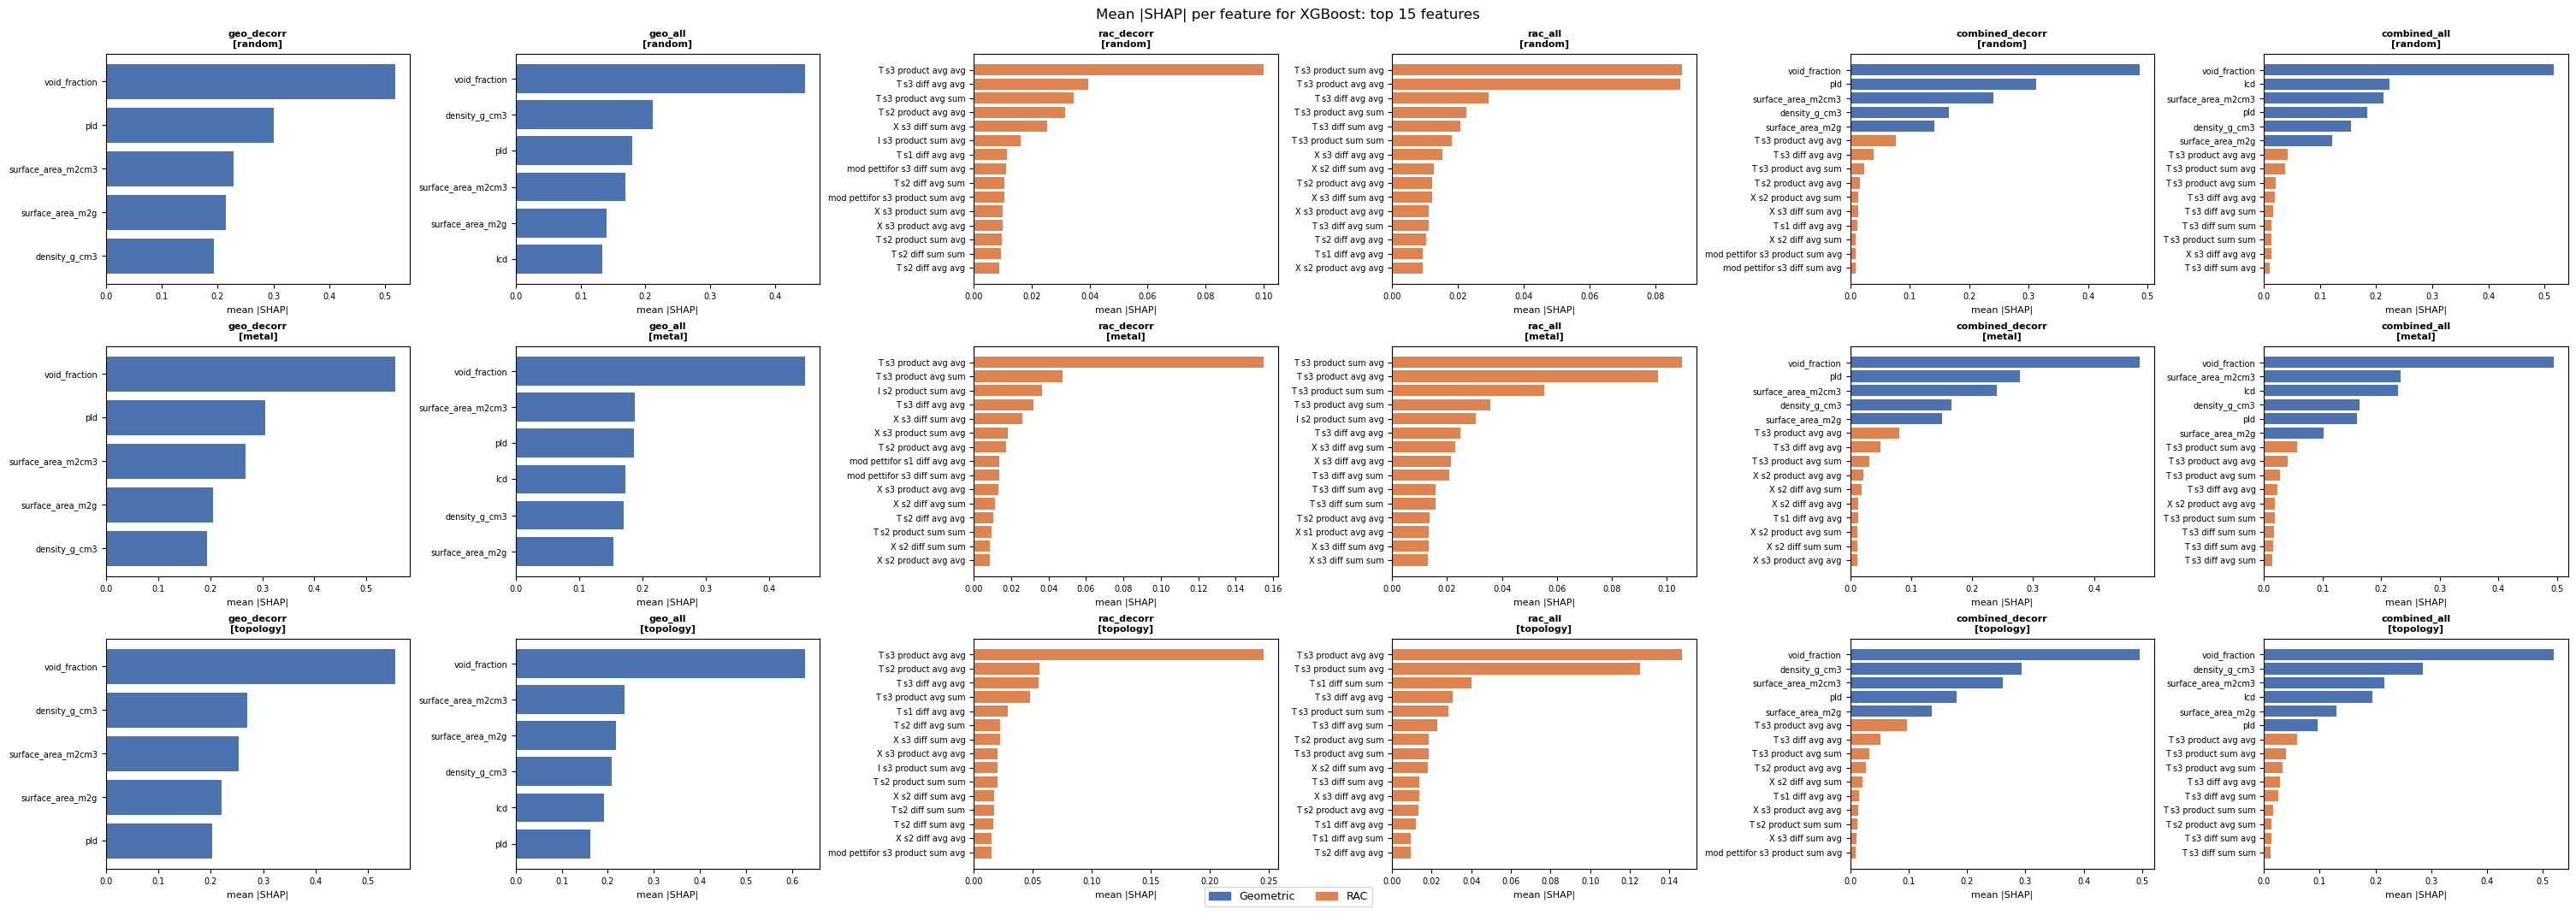

Saved shap_bar_all_experiments.pdf/png


In [5]:
# mean SHAP bar plots for each experiment
TOP_N = 15   # features to show per plot

fig, axes = plt.subplots(
    len(SPLITS), len(FEATURE_SETS),
    figsize=(5 * len(FEATURE_SETS), 3.5 * len(SPLITS)),
    constrained_layout=True,
)

for row, sp in enumerate(SPLITS):
    for col, fs in enumerate(FEATURE_SETS):
        ax  = axes[row][col]
        tag = f"{fs}__{sp}"

        if tag not in results:
            ax.set_visible(False)
            continue

        top    = mean_abs_shap(results[tag], top_n=TOP_N)
        labels = [shorten(f) for f in top.index]
        colors = [GEO_COLOUR if is_geo(f) else RAC_COLOUR for f in top.index]

        ax.barh(range(len(top)), top.values[::-1], color=colors[::-1], edgecolor="none")
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(labels[::-1], fontsize=7)
        ax.set_xlabel("mean |SHAP|", fontsize=8)

        title = f"{fs}\n[{sp}]"
        ax.set_title(title, fontsize=8, fontweight="bold")
        ax.tick_params(axis="x", labelsize=7)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=GEO_COLOUR, label="Geometric"),
                  Patch(color=RAC_COLOUR,  label="RAC")]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Mean |SHAP| per feature for XGBoost: top 15 features", fontsize=12)
plt.savefig(RESULTS_DIR / "shap_bar_all_experiments.pdf", bbox_inches="tight")
plt.savefig(RESULTS_DIR / "shap_bar_all_experiments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_bar_all_experiments.pdf/png")


Cross-split comparison: how does importance shift across splits?

For combined_all, shows the top-15 features on the random split and tracks their absolute SHAP across all three split strategies.

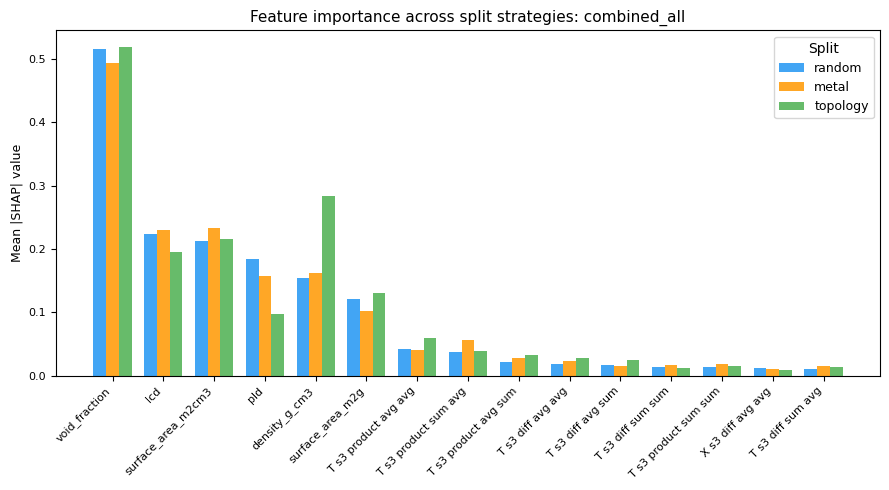

Saved shap_cross_split_combined_all.pdf/png


In [6]:
fs = "combined_all"

# Anchor feature order on random split top-15
anchor_tag = f"{fs}__random"
if anchor_tag in results:
    top_feats = mean_abs_shap(results[anchor_tag], top_n=15).index.tolist()

    data = {}
    for sp in SPLITS:
        tag = f"{fs}__{sp}"
        if tag in results:
            imp = mean_abs_shap(results[tag])
            data[sp] = [imp.get(f, 0.0) for f in top_feats]

    df_cross = pd.DataFrame(data, index=[shorten(f) for f in top_feats])

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(top_feats))
    width = 0.25
    colors_split = {"random": "#2196F3", "metal": "#FF9800", "topology": "#4CAF50"}

    for k, (sp, vals) in enumerate(df_cross.items()):
        bars = ax.bar(x + k * width, vals, width, label=sp,
                      color=colors_split.get(sp, "gray"), alpha=0.85, edgecolor="none")

    ax.set_xticks(x + width)
    ax.set_xticklabels(df_cross.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean |SHAP| value", fontsize=9)
    ax.set_title(f"Feature importance across split strategies: {fs}", fontsize=11)
    ax.legend(title="Split", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "shap_cross_split_combined_all.pdf", bbox_inches="tight")
    plt.savefig(RESULTS_DIR / "shap_cross_split_combined_all.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved shap_cross_split_combined_all.pdf/png")


Geometric vs. RAC total SHAP contribution

For combined feature sets, aggregate total mean absolute SHAP by feature type across all split strategies. 

-> does the advantage of chemical descriptors hold under non-random splits?

    feature_set    split  geo_share  rac_share
combined_decorr   random  78.770784  21.229216
combined_decorr    metal  75.672970  24.327030
combined_decorr topology  76.882148  23.117852
   combined_all   random  77.172325  22.827675
   combined_all    metal  72.987450  27.012550
   combined_all topology  76.257484  23.742516


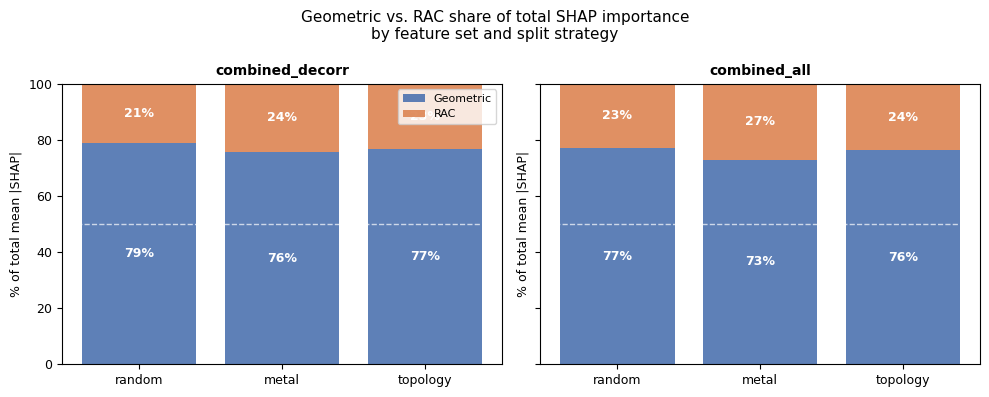

Saved shap_geo_vs_rac_contribution.pdf/png


In [7]:
combined_sets = ["combined_decorr", "combined_all"]
records = []

for fs in combined_sets:
    for sp in SPLITS:
        tag = f"{fs}__{sp}"
        if tag not in results:
            continue
        imp = mean_abs_shap(results[tag])
        geo_total = imp[[f for f in imp.index if     is_geo(f)]].sum()
        rac_total = imp[[f for f in imp.index if not is_geo(f)]].sum()
        total     = geo_total + rac_total
        records.append({
            "feature_set":  fs,
            "split":        sp,
            "geo_share":    geo_total / total * 100,
            "rac_share":    rac_total / total * 100,
            "geo_abs":      geo_total,
            "rac_abs":      rac_total,
        })

df_contrib = pd.DataFrame(records)
print(df_contrib[["feature_set", "split", "geo_share", "rac_share"]].to_string(index=False))

# Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, fs in zip(axes, combined_sets):
    sub = df_contrib[df_contrib["feature_set"] == fs].set_index("split")
    sub = sub.reindex(SPLITS)

    ax.bar(SPLITS, sub["geo_share"], color=GEO_COLOUR, label="Geometric", alpha=0.9)
    ax.bar(SPLITS, sub["rac_share"], bottom=sub["geo_share"],
           color=RAC_COLOUR, label="RAC", alpha=0.9)

    ax.set_ylim(0, 100)
    ax.set_ylabel("% of total mean |SHAP|", fontsize=9)
    ax.set_title(fs, fontsize=10, fontweight="bold")
    ax.axhline(50, color="white", linewidth=1, linestyle="--", alpha=0.7)
    ax.tick_params(labelsize=9)

    for i, sp in enumerate(SPLITS):
        if sp in sub.index:
            geo_s = sub.loc[sp, "geo_share"]
            rac_s = sub.loc[sp, "rac_share"]
            ax.text(i, geo_s / 2, f"{geo_s:.0f}%",
                    ha="center", va="center", color="white", fontsize=9, fontweight="bold")
            ax.text(i, geo_s + rac_s / 2, f"{rac_s:.0f}%",
                    ha="center", va="center", color="white", fontsize=9, fontweight="bold")

axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Geometric vs. RAC share of total SHAP importance\nby feature set and split strategy",
             fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "shap_geo_vs_rac_contribution.pdf", bbox_inches="tight")
plt.savefig(RESULTS_DIR / "shap_geo_vs_rac_contribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_geo_vs_rac_contribution.pdf/png")


Beeswarm plots

combined_all across splits

-> magnitude and direction of each feature's effect

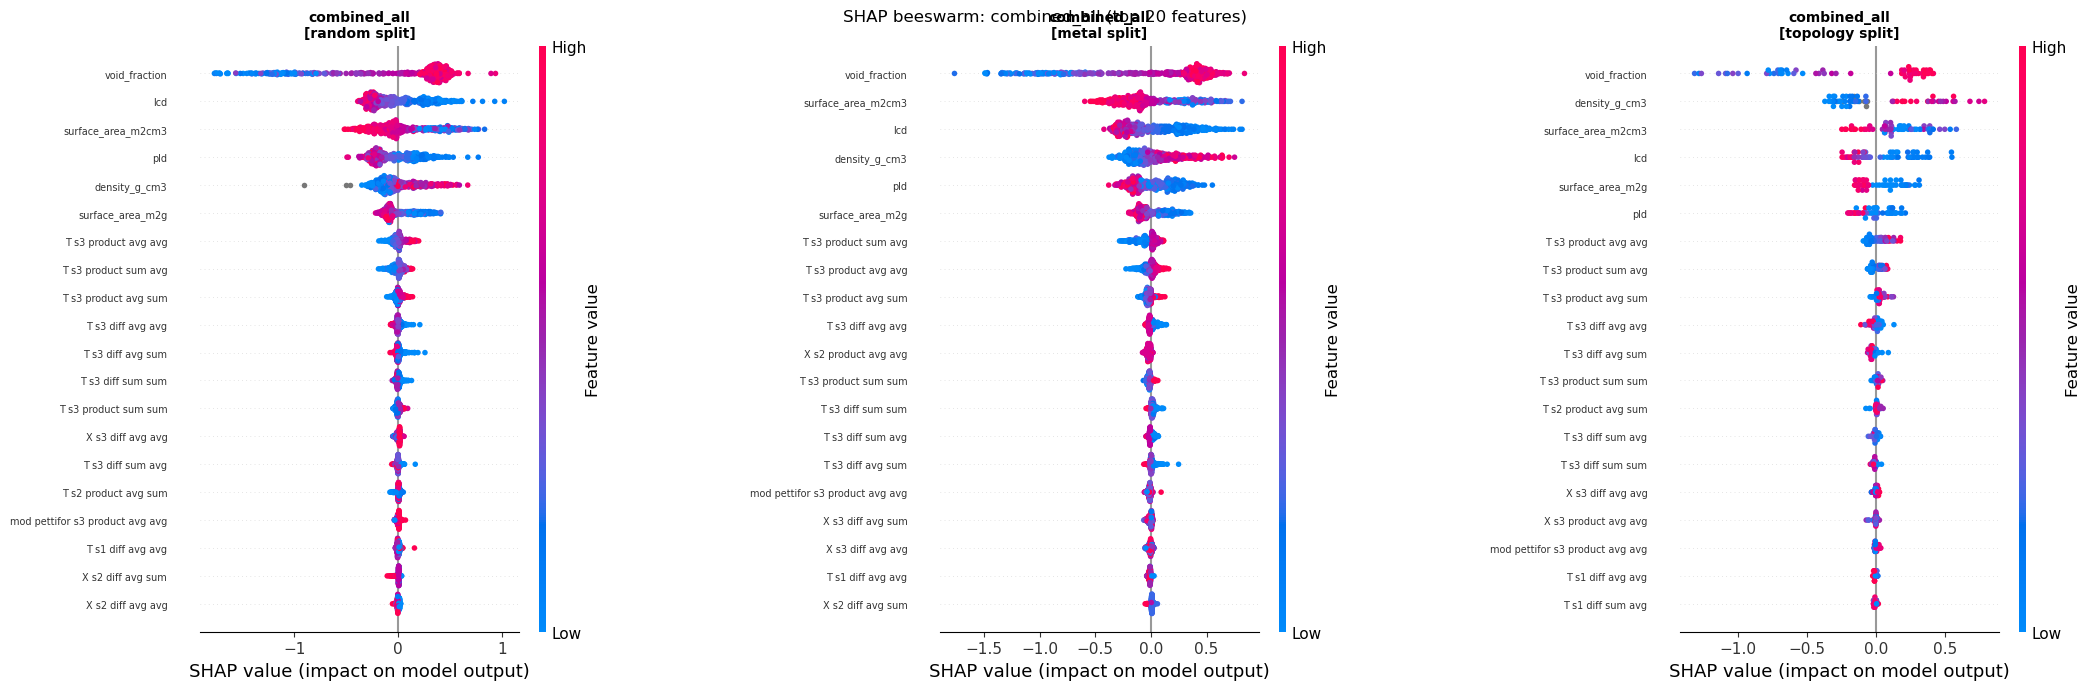

Saved shap_beeswarm_combined_all.pdf/png


In [8]:
fs = "combined_all"
TOP_N_BEE = 20

fig, axes = plt.subplots(1, len(SPLITS), figsize=(7 * len(SPLITS), 7))

for ax, sp in zip(axes, SPLITS):
    tag = f"{fs}__{sp}"
    if tag not in results:
        ax.set_visible(False)
        continue

    r         = results[tag]
    sv        = r["shap_values"]       # (n, n_features)
    feat_names = r["feature_names"]

    # Select top-N features by mean |SHAP|
    mean_imp  = np.abs(sv).mean(axis=0)
    top_idx   = np.argsort(mean_imp)[::-1][:TOP_N_BEE]
    sv_top    = sv[:, top_idx]
    X_top     = r["X_explain"][:, top_idx]
    names_top = [shorten(feat_names[i]) for i in top_idx]
    colors_top = [GEO_COLOUR if is_geo(feat_names[i]) else RAC_COLOUR for i in top_idx]

    # Manual beeswarm using stripplot-style scatter
    plt.sca(ax)
    shap.summary_plot(
        sv_top, X_top,
        feature_names=names_top,
        max_display=TOP_N_BEE,
        show=False,
        plot_size=None,
        color_bar=True,
    )
    ax.set_title(f"{fs}\n[{sp} split]", fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("SHAP beeswarm: combined_all (top 20 features)", fontsize=12)
plt.savefig(RESULTS_DIR / "shap_beeswarm_combined_all.pdf", bbox_inches="tight")
plt.savefig(RESULTS_DIR / "shap_beeswarm_combined_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved shap_beeswarm_combined_all.pdf/png")

Summary -> top features per condition

csv output

In [9]:
rows = []
for tag, r in results.items():
    imp = mean_abs_shap(r)
    for feat, val in imp.items():
        rows.append({
            "experiment":   tag,
            "feature_set":  r["feature_set"],
            "split":        r["split"],
            "feature":      feat,
            "feature_type": "geo" if is_geo(feat) else "rac",
            "mean_abs_shap": val,
        })

df_shap = pd.DataFrame(rows)
out_csv = RESULTS_DIR / "shap_importances.csv"
df_shap.to_csv(out_csv, index=False)
print(f"Saved {out_csv}  ({len(df_shap):,} rows)")

# Quick pivot: top-5 features per experiment
print("\nTop-5 features per experiment (mean |SHAP|):")
for tag, grp in df_shap.groupby("experiment"):
    top5 = grp.nlargest(5, "mean_abs_shap")[["feature", "feature_type", "mean_abs_shap"]]
    print(f"\n  {tag}")
    for _, row in top5.iterrows():
        print(f"    {row['mean_abs_shap']:.4f}  [{row['feature_type']}]  {shorten(row['feature'])}")


Saved /Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/05 - ETH/06 - FS 2026/04 - Digital Chemistry/dc_project/results/xgb/shap/shap_importances.csv  (822 rows)

Top-5 features per experiment (mean |SHAP|):

  combined_all__metal
    0.4942  [geo]  void_fraction
    0.2326  [geo]  surface_area_m2cm3
    0.2292  [geo]  lcd
    0.1626  [geo]  density_g_cm3
    0.1581  [geo]  pld

  combined_all__random
    0.5163  [geo]  void_fraction
    0.2234  [geo]  lcd
    0.2128  [geo]  surface_area_m2cm3
    0.1835  [geo]  pld
    0.1547  [geo]  density_g_cm3

  combined_all__topology
    0.5191  [geo]  void_fraction
    0.2841  [geo]  density_g_cm3
    0.2151  [geo]  surface_area_m2cm3
    0.1946  [geo]  lcd
    0.1300  [geo]  surface_area_m2g

  combined_decorr__metal
    0.4746  [geo]  void_fraction
    0.2778  [geo]  pld
    0.2400  [geo]  surface_area_m2cm3
    0.1661  [geo]  density_g_cm3
    0.1501  [geo]  surface_area_m2g

  combined_decorr__random
    0.4866  [geo]